# load data

In [14]:
import pandas as pd
import numpy as np
import os
import sys
from settings import PROJECT_ROOT, DATA_ROOT, DATASET_ROOT

# Add the project root to sys.path so Python can find your custom modules
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)



In [15]:
# Load the CSV counts and DE/GSEA results
circ_counts = pd.read_csv(os.path.join(DATASET_ROOT, '03_QCed_data', 'circ_counts_post_filtering_circ_linear_and_1cnt_in.25samples_ERVIN_202504.csv'))
de_results = pd.read_csv(os.path.join(DATASET_ROOT, '04_DE_Analysis_results/01-Pre_vs_Post_treatment/PrevsPost_ERVIN_DE_results_20250612.csv'))
gsea_results = pd.read_csv(os.path.join(DATASET_ROOT, '04_DE_Analysis_results/01-Pre_vs_Post_treatment/PrevsPost_ERVIN_DE_GSEA_results20250624.csv'))

print("Circ counts shape:", circ_counts.shape)
print("DE results shape:", de_results.shape)
print("GSEA results shape:", gsea_results.shape)

Circ counts shape: (1991, 35)
DE results shape: (25182, 9)
GSEA results shape: (15, 11)


In [16]:
# Load the Clinical Manifest (requires openpyxl)
manifest = pd.read_excel(os.path.join(DATASET_ROOT, '01_raw_data', 'ERVIN_All-Samples-Manifest_20250401.xlsx'))
print("Manifest shape:", manifest.shape)
manifest.head(3)

Manifest shape: (42, 14)


,UNM Sample ID,UNM Patient ID,UNM Visit ID,Submission Number,MGI Service Number,Submission Date,Submission Type,Submitted Tube Label,Concentration (ng/uL),Volume (ul),Container or Plate Name,Position,MGI Library ID,Notes
0,3,unknown,unknown,1,SR006206,2024-10-21,RNA,3,56.000000,16.415816,Quinn_ERVIN_01,A01,157865,NaN
1,4,unknown,unknown,1,SR006206,2024-10-21,RNA,4,26.885714,34.000000,Quinn_ERVIN_01,B01,157866,NaN
2,5,unknown,unknown,1,SR006206,2024-10-21,RNA,5,56.000000,20.732143,Quinn_ERVIN_01,C01,157867,NaN


# analyze stats

=== Gene Annotation Statistics ===


,Annotation Status,Number of circRNAs
0,Unannotated,1030
1,Annotated,961



=== Start-End Region Statistics ===


,Start-End Region,Number of circRNAs
0,intergenic-intergenic,1085
1,exon-exon,748
2,intron-intron,67
3,exon-intron,22
4,intergenic-intron,19
5,intron-exon,18
6,intron-intergenic,15
7,exon-intergenic,13
8,intergenic-exon,4


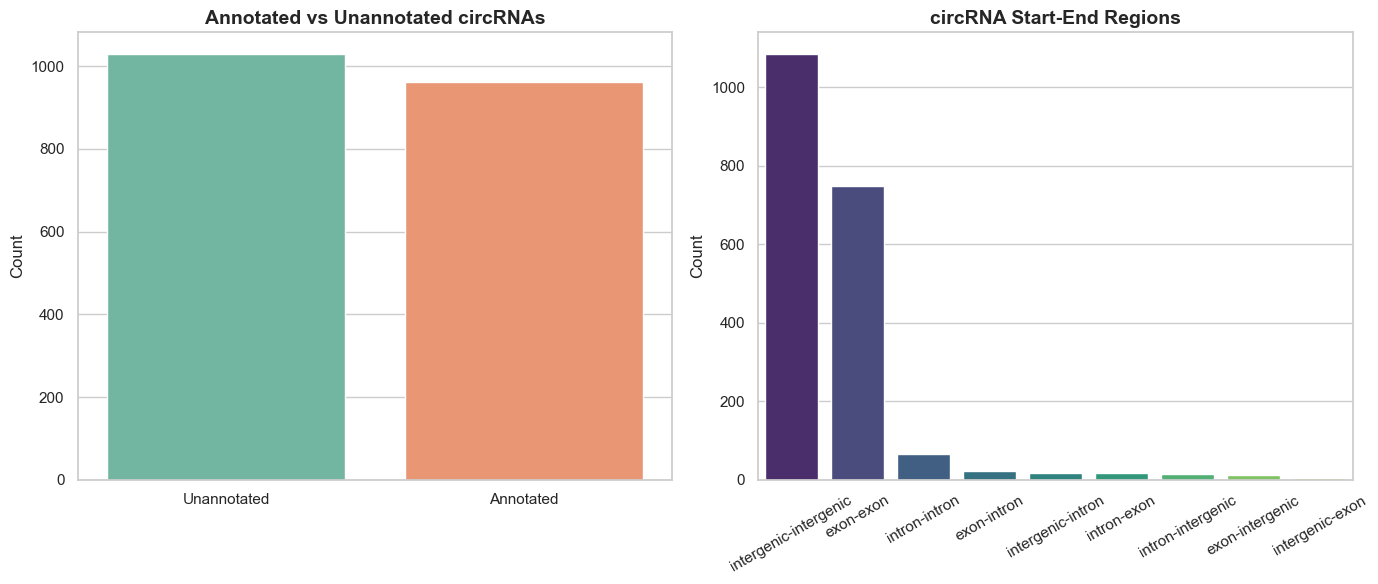

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set a clean visual style for the plots
sns.set_theme(style="whitegrid")

# --- 1. Gene Annotation Stats ---
# Categorize features as 'Unannotated' if 'not_annotated', otherwise 'Annotated'
circ_counts['Annotation_Status'] = circ_counts['Gene'].apply(
    lambda x: 'Unannotated' if x == 'not_annotated' else 'Annotated'
)

# Calculate counts and create a summary table
annotation_stats = circ_counts['Annotation_Status'].value_counts().reset_index()
annotation_stats.columns = ['Annotation Status', 'Number of circRNAs']
print("=== Gene Annotation Statistics ===")
display(annotation_stats)

# --- 2. Start-End Region Stats ---
# Calculate counts for the regions and create a summary table
region_stats = circ_counts['Start-End Region'].value_counts().reset_index()
region_stats.columns = ['Start-End Region', 'Number of circRNAs']
print("\n=== Start-End Region Statistics ===")
display(region_stats)

# --- 3. Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Annotated vs Unannotated
sns.barplot(
    data=annotation_stats, 
    x='Annotation Status', 
    y='Number of circRNAs', 
    ax=axes[0], 
    hue='Annotation Status',
    palette="Set2",
    legend=False
)
axes[0].set_title('Annotated vs Unannotated circRNAs', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')

# Plot 2: Start-End Region
sns.barplot(
    data=region_stats, 
    x='Start-End Region', 
    y='Number of circRNAs', 
    ax=axes[1], 
    hue='Start-End Region',
    palette="viridis",
    legend=False
)
axes[1].set_title('circRNA Start-End Regions', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
# Rotate x-axis labels slightly for readability
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## find genes producing >1 distinct circRNA 

In [18]:
# Filter the dataframe to drop the 'not_annotated' rows
annotated_circs = circ_counts[circ_counts['Gene'] != 'not_annotated']

# Count how many distinct circRNA loops come from each parent gene
top_genes = annotated_circs['Gene'].value_counts().reset_index()
top_genes.columns = ['Parent Gene', 'Number of Distinct circRNAs']

# --- NEW: Calculate how many genes appear more than once ---
total_unique_genes = len(top_genes)
multi_circ_genes = len(top_genes[top_genes['Number of Distinct circRNAs'] > 1])
percentage = (multi_circ_genes / total_unique_genes) * 100

print(f"Total unique annotated parent genes: {total_unique_genes}")
print(f"Genes producing >1 distinct circRNA: {multi_circ_genes} ({percentage:.1f}%)\n")
# -----------------------------------------------------------

print("=== Top 20 Parent Genes by circRNA Diversity ===")
display(top_genes.head(20))


Total unique annotated parent genes: 709
Genes producing >1 distinct circRNA: 155 (21.9%)

=== Top 20 Parent Genes by circRNA Diversity ===


,Parent Gene,Number of Distinct circRNAs
0,SOX6,14
1,FLACC1,11
2,DENND4A,8
3,RAB11A,7
4,UBAP2,7
5,MBOAT2,6
6,PHC3,6
7,TFRC,6
8,PHLPP2,5
9,SUCO,4


## counts sparsity

Total Subjects Evaluated: 27
=== circRNA Prevalence Across Subjects ===


,Number of Subjects,Number of Distinct circRNAs
0,27,20
1,26,13
2,25,13
3,24,21
4,23,16
5,22,15
6,21,16
7,20,22
8,19,15
9,18,22


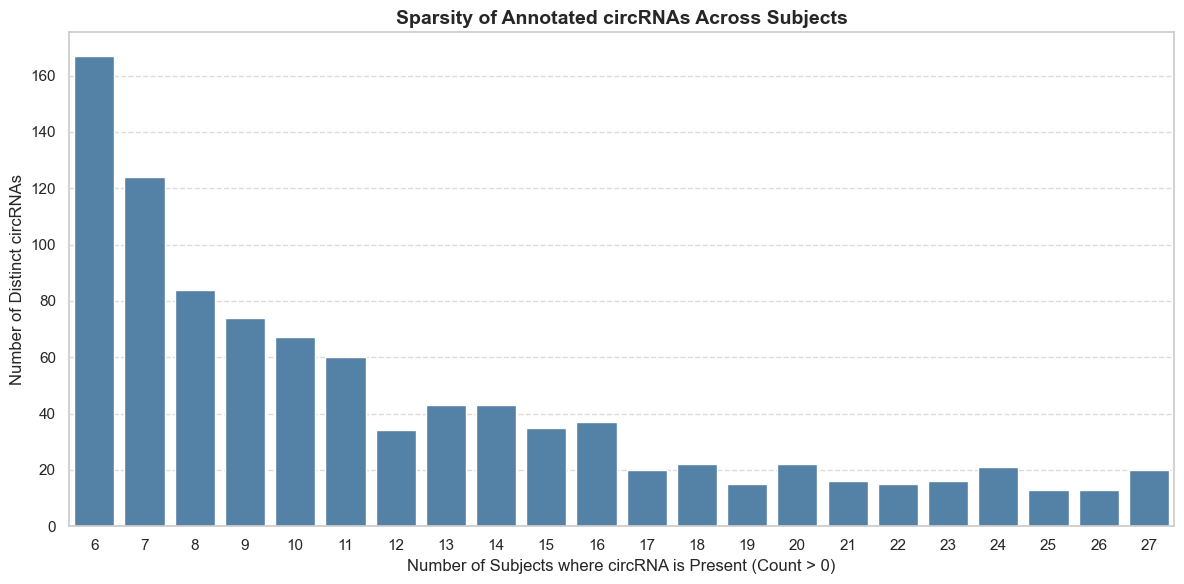

In [19]:
# 1. Filter for only the annotated circRNAs
annotated_circs = circ_counts[circ_counts['Gene'] != 'not_annotated'].copy()

# 2. Automatically find all the columns that contain sample counts
sample_cols = [col for col in annotated_circs.columns if col.startswith('sample_')]
num_subjects = len(sample_cols)

# 3. For each circRNA (row), count how many subjects have a count > 0
annotated_circs['Subject_Count'] = (annotated_circs[sample_cols] > 0).sum(axis=1)

# 4. Tally up how many circRNAs appear in exactly X subjects
prevalence_stats = annotated_circs['Subject_Count'].value_counts().sort_index(ascending=False).reset_index()
prevalence_stats.columns = ['Number of Subjects', 'Number of Distinct circRNAs']

# Display the numerical table
print(f"Total Subjects Evaluated: {num_subjects}")
print("=== circRNA Prevalence Across Subjects ===")
display(prevalence_stats)

# 5. Plot the histogram / bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=prevalence_stats,
    x='Number of Subjects',
    y='Number of Distinct circRNAs',
    color='steelblue'
)

plt.title('Sparsity of Annotated circRNAs Across Subjects', fontsize=14, fontweight='bold')
plt.xlabel('Number of Subjects where circRNA is Present (Count > 0)', fontsize=12)
plt.ylabel('Number of Distinct circRNAs', fontsize=12)

# Add a subtle grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Total circRNAs evaluated (from multi-producer genes): 407
=== Prevalence of circRNAs from Multi-Producer Genes ===


,Number of Subjects,Number of Distinct circRNAs
0,27,11
1,26,6
2,25,3
3,24,9
4,23,6
5,22,7
6,21,5
7,20,13
8,19,10
9,18,13


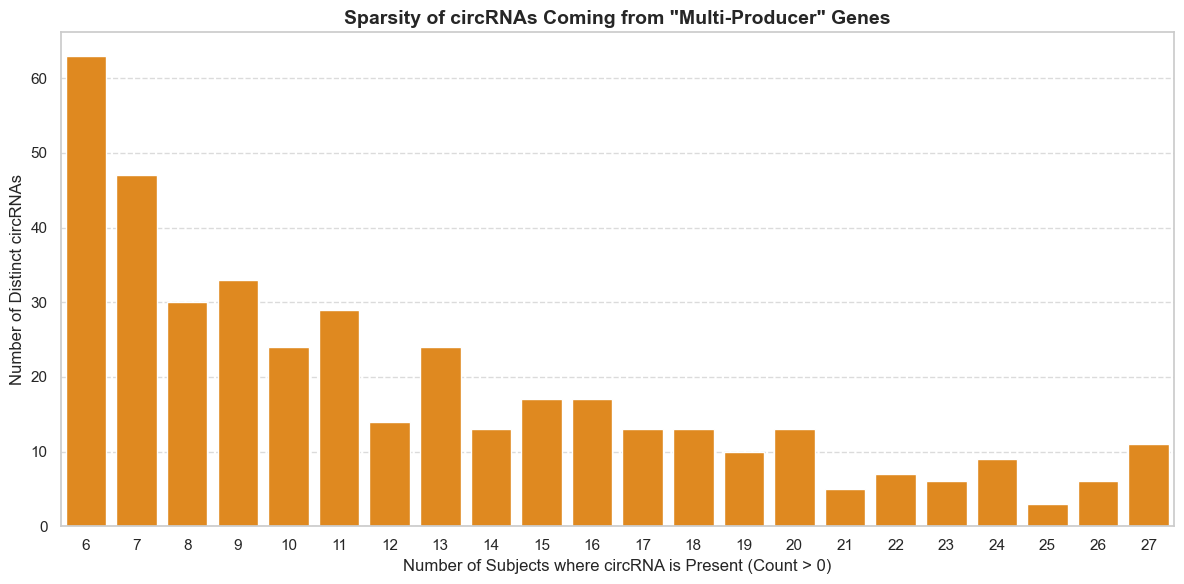

In [20]:
# 1. Identify parent genes that produce MORE THAN ONE distinct circRNA
gene_counts = annotated_circs['Gene'].value_counts()
multi_producer_genes = gene_counts[gene_counts > 1].index

# 2. Filter the dataframe to only include circRNAs from these multi-producer genes
multi_circ_df = annotated_circs[annotated_circs['Gene'].isin(multi_producer_genes)].copy()

# 3. Automatically find all the columns that contain sample counts
sample_cols = [col for col in multi_circ_df.columns if col.startswith('sample_')]
num_subjects = len(sample_cols)

# 4. Count how many subjects have a count > 0 for these specific circRNAs
multi_circ_df['Subject_Count'] = (multi_circ_df[sample_cols] > 0).sum(axis=1)

# 5. Tally up how many of these circRNAs appear in exactly X subjects
prevalence_stats_multi = multi_circ_df['Subject_Count'].value_counts().sort_index(ascending=False).reset_index()
prevalence_stats_multi.columns = ['Number of Subjects', 'Number of Distinct circRNAs']

# Display the numerical table
print(f"Total circRNAs evaluated (from multi-producer genes): {len(multi_circ_df)}")
print("=== Prevalence of circRNAs from Multi-Producer Genes ===")
display(prevalence_stats_multi)

# 6. Plot the histogram / bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=prevalence_stats_multi,
    x='Number of Subjects',
    y='Number of Distinct circRNAs',
    color='darkorange'
)

plt.title('Sparsity of circRNAs Coming from "Multi-Producer" Genes', fontsize=14, fontweight='bold')
plt.xlabel('Number of Subjects where circRNA is Present (Count > 0)', fontsize=12)
plt.ylabel('Number of Distinct circRNAs', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


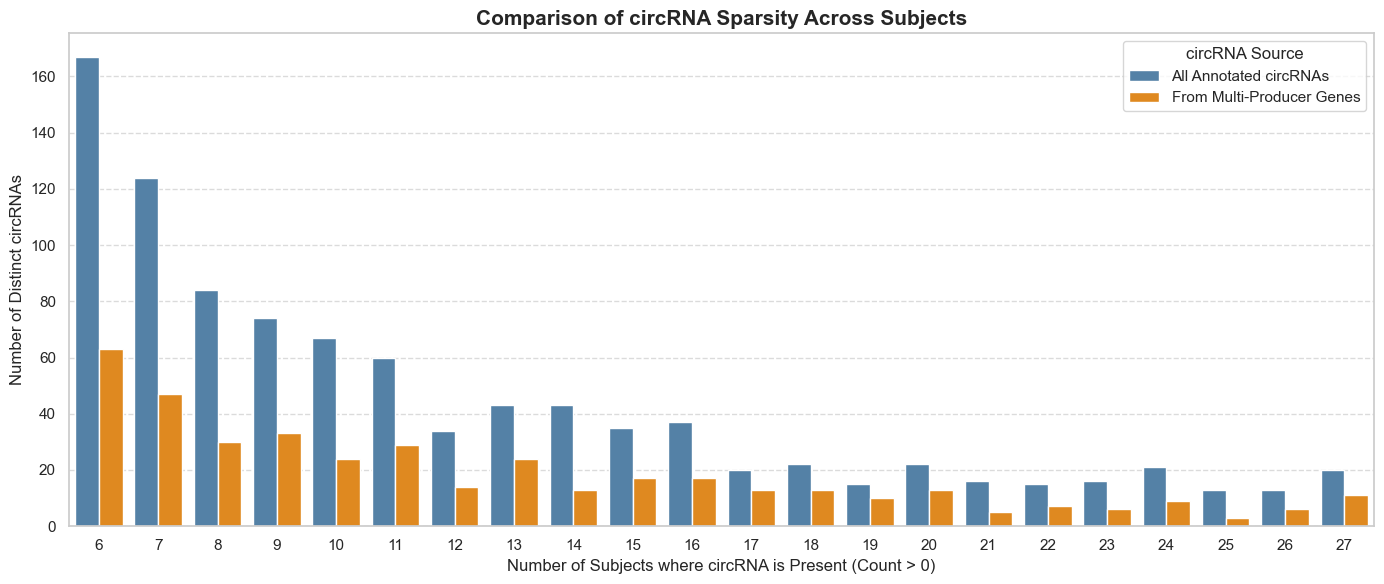

In [21]:
import pandas as pd

# 1. Add a descriptive label to copies of your existing dataframes
df_all = prevalence_stats.copy()
df_all['Category'] = 'All Annotated circRNAs'

df_multi = prevalence_stats_multi.copy()
df_multi['Category'] = 'From Multi-Producer Genes'

# 2. Combine them into a single "long-form" dataframe
combined_stats = pd.concat([df_all, df_multi], ignore_index=True)

# 3. Plot them side-by-side on the same axis
plt.figure(figsize=(14, 6))
sns.barplot(
    data=combined_stats,
    x='Number of Subjects',
    y='Number of Distinct circRNAs',
    hue='Category',
    palette=['steelblue', 'darkorange']
)

plt.title('Comparison of circRNA Sparsity Across Subjects', fontsize=15, fontweight='bold')
plt.xlabel('Number of Subjects where circRNA is Present (Count > 0)', fontsize=12)
plt.ylabel('Number of Distinct circRNAs', fontsize=12)

# Make the legend look clean
plt.legend(title='circRNA Source', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# map IDs to demographic data

In [22]:
# clean demographics data

import pandas as pd
from IPython.display import display

# 1. Load the demo clinical data

demo_data_path = os.path.join(DATASET_ROOT, 'demo_data.csv')
demo_df = pd.read_csv(demo_data_path)

# 2. Filter out the duplicates/exclusions (Drop rows where Exclude == 1)
# This safely keeps 0 and 2.
filtered_demo_df = demo_df[demo_df['Exclude'] != 1].copy()

# 3. Select only the columns of interest
columns_to_keep = [
    'Sample_ID', 'URSI', 'Age', 'Sex', 'Visit', 'Treatment Status', 
    'SHAPSC', 'TEPS', 'IDS-C', 'GAD-7', 'YMRS', 'Response'
]
filtered_demo_df = filtered_demo_df[columns_to_keep]

filtered_demo_df['map_id'] = filtered_demo_df['URSI'] + '_V' + filtered_demo_df['Visit'].astype(str)
filtered_demo_df.insert(1, 'map_id', filtered_demo_df.pop('map_id'))


filtered_demo_df.sort_values(by=['URSI', 'Visit'], inplace=True)
# 5. Save the clean, sorted dataframe as a CSV
output_path = os.path.join(DATA_ROOT, 'clean_clinical_metadata.csv')
# index=False ensures we don't save the default 0,1,2,3 row numbers into the file
filtered_demo_df.to_csv(output_path, index=False)
print(f"Cleaned and sorted metadata successfully saved to:\n{output_path}")

# GET STATS
df = filtered_demo_df

print("=== Demographic & Clinical Summary ===\n")

# 1. Unique Patients vs Total Samples
num_unique_patients = df['URSI'].nunique()
print(f"Total Unique Patients: {num_unique_patients}")
print(f"Total Samples (Sequencing runs): {len(df)}\n")

# 2. Treatment Status Distribution (This is counted per sample)
print("--- Samples by Treatment Status ---")
print(df['Treatment Status'].value_counts().to_string())
print()

# 3. Demographics (Grouped by patient to avoid double-counting)
patient_level_df = df.drop_duplicates(subset=['URSI'])

print("--- Patient Sex Breakdown ---")
print(patient_level_df['Sex'].value_counts().to_string())
print()

# 4. Age Statistics (Grouped by patient)
age_stats = patient_level_df['Age'].describe()
print("--- Patient Age Statistics ---")
print(f"Mean Age:  {age_stats['mean']:.1f} years")
print(f"Min Age:   {age_stats['min']:.0f} years")
print(f"Max Age:   {age_stats['max']:.0f} years")



Cleaned and sorted metadata successfully saved to:
/Users/ppopov1/_circRNA/docs/01_on_data/data/clean_clinical_metadata.csv
=== Demographic & Clinical Summary ===

Total Unique Patients: 9
Total Samples (Sequencing runs): 24

--- Samples by Treatment Status ---
Treatment Status
Post      9
Pre       8
During    7

--- Patient Sex Breakdown ---
Sex
Male      5
Female    4

--- Patient Age Statistics ---
Mean Age:  38.1 years
Min Age:   22 years
Max Age:   67 years


In [23]:
# use cleaned data to remap sample IDs to URSI_Visit
import pandas as pd

# 1. Load the clean metadata we just created
clean_meta_path = os.path.join(DATA_ROOT, 'clean_clinical_metadata.csv')
clean_meta = pd.read_csv(clean_meta_path)

# 2. Create the mapping dictionary: { 'sample_10' : 'M87149891_V2' }
mapping_dict = {}
for _, row in clean_meta.iterrows():
    mapping_dict[row['Sample_ID']] = row['map_id']

print("Mapping dictionary created! Examples:")
for k, v in list(mapping_dict.items())[:3]:
    print(f"  {k}  ->  {v}")

# 3. Apply mapping to Circular RNA counts (assuming 'circ_counts' is still loaded)
circ_counts_mapped = circ_counts.rename(columns=mapping_dict)

# Keep only the metadata columns (first 8) + the newly mapped sample columns
# This inherently drops any samples that were 'Excluded' in our clinical data!
circ_meta_cols = list(circ_counts.columns[:8])
valid_circ_cols = circ_meta_cols + list(mapping_dict.values())
circ_counts_mapped = circ_counts_mapped[valid_circ_cols]

circ_counts_mapped.insert(0, 'circRNA_id', circ_counts_mapped.pop('chr_start_end_strand'))

# Save the mapped circular counts
circ_out_path = os.path.join(DATA_ROOT, 'circRNA_counts.csv')
circ_counts_mapped.to_csv(circ_out_path, index=False)
print(f"\nSaved mapped circular counts to:\n  {circ_out_path}")

# 4. Load, map, and save the Linear RNA counts
linear_path = os.path.join(DATASET_ROOT, '03_QCed_data', '202504_ERVIN_filtered_linear_gene_counts.csv')
lin_counts = pd.read_csv(linear_path)

lin_counts_mapped = lin_counts.rename(columns=mapping_dict)

# Keep only the newly mapped sample columns + the 'gene_id' column
valid_lin_cols = list(mapping_dict.values()) + ['gene_id']
lin_counts_mapped = lin_counts_mapped[valid_lin_cols]

lin_counts_mapped.insert(0, 'gene_id', lin_counts_mapped.pop('gene_id'))

lin_out_path = os.path.join(DATA_ROOT, 'linRNA_counts.csv')
lin_counts_mapped.to_csv(lin_out_path, index=False)
print(f"Saved mapped linear counts to:\n  {lin_out_path}")


Mapping dictionary created! Examples:
  sample_20  ->  M87114859_V1
  sample_21  ->  M87114859_V2
  sample_3  ->  M87114859_V3

Saved mapped circular counts to:
  /Users/ppopov1/_circRNA/docs/01_on_data/data/circRNA_counts.csv
Saved mapped linear counts to:
  /Users/ppopov1/_circRNA/docs/01_on_data/data/linRNA_counts.csv
